# 관련 단축키 설명

## 1. 셀 코드 실행

Shift + Enter: 현재 셀을 실행하고 다음 셀로 이동합니다. (가장 많이 사용)

Ctrl + Enter: 현재 셀을 실행하고 현재 셀에 머무릅니다. 결과를 확인하고 코드를 계속 수정할 때 유용합니다. (Mac: Cmd + Enter)

Alt + Enter: 현재 셀을 실행하고 바로 아래에 새로운 코드 셀을 추가합니다. (Mac: Option + Enter)

## 2. 셀 삭제

명령 모드(Esc) 상태에서:

D , D: 키보드 알파벳 D를 연속으로 두 번 타닥 누르면 셀이 삭제됩니다.

## 3. 코드 셀 만들기

명령 모드(Esc) 상태에서:

* A: 현재 셀 위(Above)에 새로운 코드 셀을 추가합니다.

* B: 현재 셀 아래(Below)에 새로운 코드 셀을 추가합니다.

* Y: 마크다운 등 다른 타입의 셀을 다시 코드(Code) 셀로 변경합니다.

## 4. 마크다운 셀 만들기

명령 모드(Esc) 상태에서:

M: 현재 셀을 마크다운(Markdown) 셀로 변경합니다.

실전 팁: 보통 마크다운 셀을 새로 만들 때는 **B**를 눌러 아래에 빈 코드 셀을 만든 직후, 바로 **M**을 눌러 마크다운 셀로 변환해서 글을 작성하는 방식을 가장 많이 사용합니다. 실수로 셀을 지웠다면 당황하지 말고 Z 키를 누르면 방금 삭제한 셀이 복구됩니다.

---

# **비전 노드 개발 관련 실험코드**

### 리얼센스 D435IF 기반 듀플로 단일 블럭 및 조립 객체 인식 상태 개발

---

## **리얼센스 카메라 인식 하는 함수**

In [338]:
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint

In [339]:
def list_realsense_devices():
    """
    현재 연결된 Intel RealSense 카메라 목록을 출력하는 함수
    """
    ctx = rs.context()
    devices = ctx.query_devices()

    device_count = len(devices)

    print(f"[INFO] 연결된 RealSense 장치 수: {device_count}")

    if device_count == 0:
        print("[WARN] 연결된 RealSense 카메라가 없습니다.")
        return []

    device_info_list = []

    for i, dev in enumerate(devices):
        print("\n" + "=" * 50)
        print(f"[DEVICE {i}]")

        info = {}

        for info_type in [
            rs.camera_info.name,
            rs.camera_info.serial_number,
            rs.camera_info.firmware_version,
            rs.camera_info.physical_port,
            rs.camera_info.product_id,
            rs.camera_info.product_line,
        ]:
            if dev.supports(info_type):
                key = str(info_type).split(".")[-1]
                value = dev.get_info(info_type)
                info[key] = value
                print(f"{key}: {value}")

        sensors = dev.query_sensors()
        print(f"sensor count: {len(sensors)}")

        for j, sensor in enumerate(sensors):
            sensor_name = sensor.get_info(rs.camera_info.name)
            print(f"  - Sensor {j}: {sensor_name}")

        device_info_list.append(info)

    print("\n[INFO] RealSense 장치 확인 완료")
    return device_info_list

In [340]:
devices = list_realsense_devices()

[INFO] 연결된 RealSense 장치 수: 1

[DEVICE 0]
name: Intel RealSense D435IF
serial_number: 327122072783
firmware_version: 5.17.0.10
physical_port: /sys/devices/pci0000:00/0000:00:14.0/usb2/2-8/2-8:1.0/video4linux/video0
product_id: 0B3A
product_line: D400
sensor count: 3
  - Sensor 0: Stereo Module
  - Sensor 1: RGB Camera
  - Sensor 2: Motion Module

[INFO] RealSense 장치 확인 완료


## **카메라에서 640 480 기준의 칼라, 뎁스 이미지 인트린직 요청**

In [341]:
def capture_color_depth_and_save_intrinsics(
    devices,
    image_save_path="output/realsense_color.png",
    depth_save_path="output/realsense_depth_aligned.png", 
    yaml_save_path="output/realsense_intrinsics.yaml",
    width=640,
    height=480,
    fps=30,
    warmup_frames=10,
    show=True,
    
    # --- 필터 파라미터 ---
    use_realsense_filter=True,
    use_decimation=False,  # 듀플로 경계 보존을 위해 기본 OFF
    use_spatial=True,
    spatial_magnitude=2,
    spatial_smooth_alpha=0.5,
    spatial_smooth_delta=20,
    spatial_holes_fill=0,
    use_temporal=True,
    temporal_smooth_alpha=0.4,
    temporal_smooth_delta=20,
    temporal_persistency_index=3,
    use_hole_filling=False,
    hole_filling_mode=1
):
    """
    devices의 첫 번째 RealSense 카메라에서
    color image, aligned & filtered depth image를 1장 캡처하고,
    color/depth intrinsics를 출력 및 yaml로 저장한다.
    """

    import os
    import yaml
    import cv2
    import numpy as np
    import pyrealsense2 as rs
    import matplotlib.pyplot as plt

    # ---------------------------------------------------------
    # 1. 기기 유효성 검사
    # ---------------------------------------------------------
    if devices is None or len(devices) == 0:
        raise ValueError("devices가 비어 있습니다. 먼저 list_realsense_devices()를 실행하세요.")

    first_device = devices[0]
    if "serial_number" not in first_device:
        raise KeyError("devices[0] 안에 'serial_number'가 없습니다.")

    serial_number = first_device["serial_number"]
    print(f"[INFO] 첫 번째 카메라 serial_number: {serial_number}")

    # ---------------------------------------------------------
    # 2. 파이프라인 및 스트림 설정
    # ---------------------------------------------------------
    pipeline = rs.pipeline()
    config = rs.config()

    config.enable_device(serial_number)
    config.enable_stream(rs.stream.color, width, height, rs.format.bgr8, fps)
    config.enable_stream(rs.stream.depth, width, height, rs.format.z16, fps)

    try:
        # 🔥 스트림 시작 (이후에 센서 설정 가능)
        profile = pipeline.start(config)
        print("[INFO] RealSense color/depth stream 시작")

        # 🔥 컬러 화이트 밸런스 수동 고정 (푸른 스머프 현상 방지)
        sensor = profile.get_device().first_color_sensor()
        sensor.set_option(rs.option.enable_auto_white_balance, 0)
        sensor.set_option(rs.option.white_balance, 4500) # 필요시 4000~5000 사이 조절
        print("[INFO] 화이트 밸런스 수동(4500K) 고정 완료")

        # 얼라인 객체 생성
        align = rs.align(rs.stream.color)

        # depth scale 확인
        depth_sensor = profile.get_device().first_depth_sensor()
        depth_scale = depth_sensor.get_depth_scale()
        print(f"[INFO] depth_scale: {depth_scale} meter/unit")

        # ---------------------------------------------------------
        # 3. 필터 객체 초기화
        # ---------------------------------------------------------
        if use_realsense_filter:
            depth_to_disparity = rs.disparity_transform(True)
            disparity_to_depth = rs.disparity_transform(False)
            
            if use_decimation:
                decimation = rs.decimation_filter()
            if use_spatial:
                spatial = rs.spatial_filter()
                spatial.set_option(rs.option.filter_magnitude, spatial_magnitude)
                spatial.set_option(rs.option.filter_smooth_alpha, spatial_smooth_alpha)
                spatial.set_option(rs.option.filter_smooth_delta, spatial_smooth_delta)
                spatial.set_option(rs.option.holes_fill, spatial_holes_fill)
            if use_temporal:
                temporal = rs.temporal_filter()
                temporal.set_option(rs.option.filter_smooth_alpha, temporal_smooth_alpha)
                temporal.set_option(rs.option.filter_smooth_delta, temporal_smooth_delta)
                temporal.set_option(rs.option.holes_fill, temporal_persistency_index)
            if use_hole_filling:
                hole_filling = rs.hole_filling_filter()
                hole_filling.set_option(rs.option.holes_fill, hole_filling_mode)

        # ---------------------------------------------------------
        # 4. 웜업 및 Temporal 필터 히스토리 누적
        # ---------------------------------------------------------
        for _ in range(warmup_frames):
            frames = pipeline.wait_for_frames()
            aligned_frames = align.process(frames)
            depth_frame = aligned_frames.get_depth_frame()
            
            if use_realsense_filter:
                if use_decimation: depth_frame = decimation.process(depth_frame)
                depth_frame = depth_to_disparity.process(depth_frame)
                if use_spatial: depth_frame = spatial.process(depth_frame)
                if use_temporal: depth_frame = temporal.process(depth_frame) # 과거 프레임 누적
                depth_frame = disparity_to_depth.process(depth_frame)
                if use_hole_filling: depth_frame = hole_filling.process(depth_frame)

        # ---------------------------------------------------------
        # 5. 최종 프레임 획득 및 데이터 추출
        # ---------------------------------------------------------
        frames = pipeline.wait_for_frames()
        aligned_frames = align.process(frames)

        color_frame = aligned_frames.get_color_frame()
        depth_frame = aligned_frames.get_depth_frame()

        if not color_frame: raise RuntimeError("컬러 프레임을 가져오지 못했습니다.")
        if not depth_frame: raise RuntimeError("얼라인된 뎁스 프레임을 가져오지 못했습니다.")

        # 최종 뎁스 필터 적용
        if use_realsense_filter:
            if use_decimation: depth_frame = decimation.process(depth_frame)
            depth_frame = depth_to_disparity.process(depth_frame)
            if use_spatial: depth_frame = spatial.process(depth_frame)
            if use_temporal: depth_frame = temporal.process(depth_frame)
            depth_frame = disparity_to_depth.process(depth_frame)
            if use_hole_filling: depth_frame = hole_filling.process(depth_frame)

        # numpy 배열로 변환
        image_bgr = np.asanyarray(color_frame.get_data())
        depth_image = np.asanyarray(depth_frame.get_data())

        # 🔥 최종 프레임에서 Intrinsics 추출 (필터 통과 후 해상도 변경 대비)
        color_intr = color_frame.profile.as_video_stream_profile().intrinsics
        depth_intr = depth_frame.profile.as_video_stream_profile().intrinsics

        print("\n[COLOR INTRINSICS]")
        print(f"width  : {color_intr.width}")
        print(f"height : {color_intr.height}")
        print(f"fx     : {color_intr.fx:.3f}, fy: {color_intr.fy:.3f}")
        print(f"cx     : {color_intr.ppx:.3f}, cy: {color_intr.ppy:.3f}")

    finally:
        pipeline.stop()
        print("\n[INFO] RealSense stream 종료")

    # ---------------------------------------------------------
    # 6. 결과 저장 (이미지 & YAML)
    # ---------------------------------------------------------
    for path in [image_save_path, depth_save_path, yaml_save_path]:
        save_dir = os.path.dirname(path)
        if save_dir != "":
            os.makedirs(save_dir, exist_ok=True)

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    cv2.imwrite(image_save_path, image_rgb)
    cv2.imwrite(depth_save_path, depth_image)
    print(f"[INFO] 컬러 이미지 저장 완료: {image_save_path}")
    print(f"[INFO] 뎁스 얼라인 이미지 저장 완료: {depth_save_path}")

    intrinsics_dict = {
        "device": {"serial_number": serial_number},
        "color": {
            "width": int(color_intr.width), "height": int(color_intr.height),
            "fx": float(color_intr.fx), "fy": float(color_intr.fy),
            "cx": float(color_intr.ppx), "cy": float(color_intr.ppy),
            "model": str(color_intr.model), "coeffs": [float(v) for v in color_intr.coeffs]
        },
        "depth": {
            "width": int(depth_intr.width), "height": int(depth_intr.height),
            "fx": float(depth_intr.fx), "fy": float(depth_intr.fy),
            "cx": float(depth_intr.ppx), "cy": float(depth_intr.ppy),
            "model": str(depth_intr.model), "coeffs": [float(v) for v in depth_intr.coeffs],
            "depth_scale": float(depth_scale)
        }
    }

    with open(yaml_save_path, "w", encoding="utf-8") as f:
        yaml.dump(intrinsics_dict, f, allow_unicode=True, sort_keys=False, default_flow_style=False)

    # ---------------------------------------------------------
    # 7. 시각화 (matplotlib)
    # ---------------------------------------------------------
    if show:
        depth_colormap = cv2.applyColorMap(
            cv2.convertScaleAbs(depth_image, alpha=0.03),
            cv2.COLORMAP_JET
        )
        depth_colormap_rgb = cv2.cvtColor(depth_colormap, cv2.COLOR_BGR2RGB)

        intr_text = (
            "[INTRINSICS]\n"
            f"Size   : {color_intr.width}x{color_intr.height}\n"
            f"fx     : {color_intr.fx:.3f}\n"
            f"fy     : {color_intr.fy:.3f}\n"
            f"cx     : {color_intr.ppx:.3f}\n"
            f"cy     : {color_intr.ppy:.3f}\n\n"
            "[DEPTH SCALE]\n"
            f"{depth_scale:.8f} m/unit"
        )

        fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"width_ratios": [1.1, 2, 2]})

        axes[0].axis("off")
        axes[0].set_title("Camera Settings")
        axes[0].text(0.0, 0.95, intr_text, fontsize=10, family="monospace", verticalalignment="top")

        axes[1].imshow(image_rgb)
        axes[1].set_title("Color Image (WB Locked)")
        axes[1].axis("off")

        axes[2].imshow(depth_colormap_rgb)
        axes[2].set_title("Filtered & Aligned Depth Image")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

    return image_bgr, depth_image, intrinsics_dict

[INFO] 첫 번째 카메라 serial_number: 327122072783
[INFO] RealSense color/depth stream 시작
[INFO] 화이트 밸런스 수동(4500K) 고정 완료
[INFO] depth_scale: 0.0010000000474974513 meter/unit

[COLOR INTRINSICS]
width  : 640
height : 480
fx     : 606.194, fy: 606.086
cx     : 329.096, cy: 247.071

[INFO] RealSense stream 종료
[INFO] 컬러 이미지 저장 완료: output/realsense_color.png
[INFO] 뎁스 얼라인 이미지 저장 완료: output/realsense_depth_raw.png


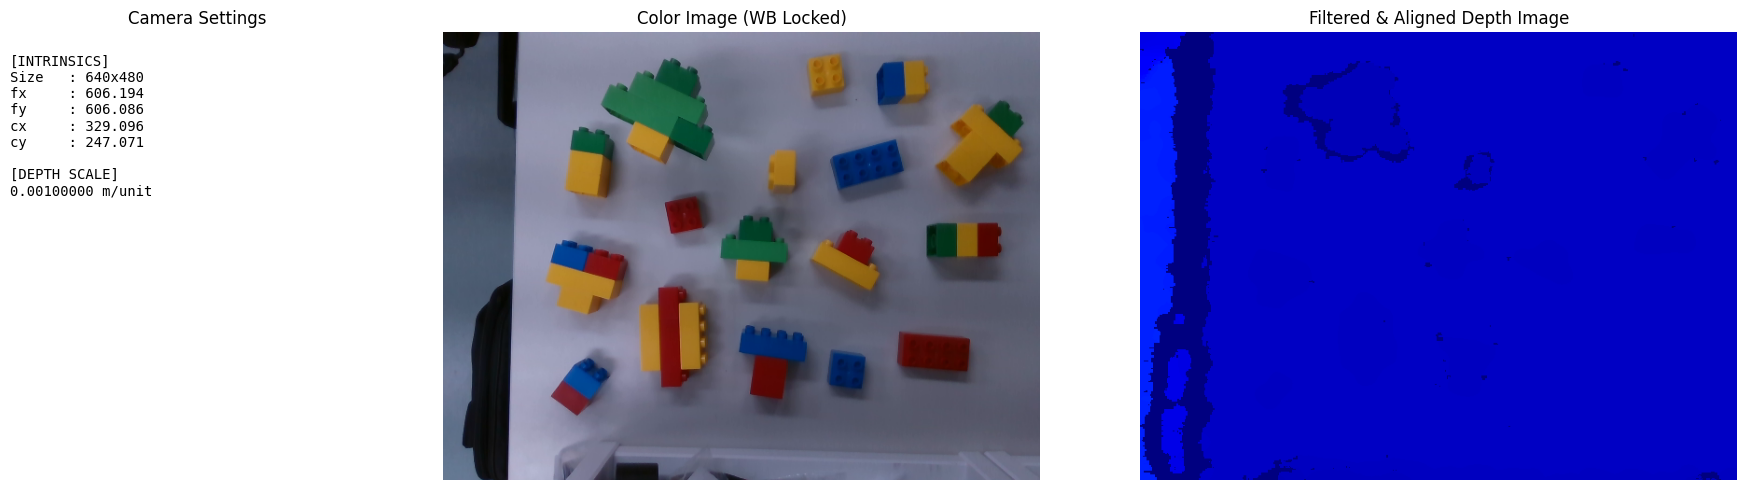

In [342]:
color_img, depth_img, intrinsics = capture_color_depth_and_save_intrinsics(
    devices=devices,
    image_save_path="output/realsense_color.png",
    depth_save_path="output/realsense_depth_raw.png",
    yaml_save_path="output/realsense_intrinsics.yaml",
    width=640,
    height=480,
    fps=30,
    warmup_frames=10,
    show=True
)

In [343]:
def apply_depth_median_filter(
    depth_img,
    ksize=5,
    valid_mask=None,
    fill_holes=True, # 🔥 0값(Invalid)에 의한 엣지 파먹힘 방지 옵션
    show=False,
    title="Depth Median Filter"
):
    """
    depth 이미지에 median filter를 적용한다.
    (선택적으로 Hole Filling을 선행하여 0값에 의한 엣지 파먹힘을 방지한다.)
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")
    if not isinstance(depth_img, np.ndarray):
        raise TypeError("depth_img는 np.ndarray 형식이어야 합니다.")
    if depth_img.ndim != 2:
        raise ValueError(f"depth_img는 2D depth 이미지여야 합니다. 현재 shape: {depth_img.shape}")
    if ksize % 2 == 0 or ksize < 3:
        raise ValueError("ksize는 최소 3 이상의 홀수여야 합니다. 예: 3, 5, 7")

    # ---------------------------------------------------------
    # [1] 0값(Invalid)에 의한 엣지 침식 방지 (Hole Filling)
    # ---------------------------------------------------------
    if fill_holes:
        kernel = np.ones((3, 3), np.uint16)
        depth_to_filter = cv2.morphologyEx(depth_img, cv2.MORPH_CLOSE, kernel)
    else:
        depth_to_filter = depth_img.copy()

    # ---------------------------------------------------------
    # [2] Median Filtering
    # ---------------------------------------------------------
    depth_filtered = cv2.medianBlur(depth_to_filter, ksize)

    # ---------------------------------------------------------
    # [3] 통계 정보 계산
    # ---------------------------------------------------------
    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = valid_mask > 0

    valid_before = depth_img[valid_bool]
    valid_after = depth_filtered[valid_bool]

    before_median, before_mean, before_std = None, None, None
    if valid_before.size > 0:
        before_median = float(np.median(valid_before))
        before_mean = float(np.mean(valid_before))
        before_std = float(np.std(valid_before))

    after_median, after_mean, after_std = None, None, None
    if valid_after.size > 0:
        after_median = float(np.median(valid_after))
        after_mean = float(np.mean(valid_after))
        after_std = float(np.std(valid_after))

    filter_info = {
        "ksize": int(ksize),
        "hole_filled": fill_holes,
        "before_median_mm": before_median,
        "before_mean_mm": before_mean,
        "before_std_mm": before_std,
        "after_median_mm": after_median,
        "after_mean_mm": after_mean,
        "after_std_mm": after_std,
    }

    # ---------------------------------------------------------
    # [4] 시각화 (show=True 일 때만 작동)
    # ---------------------------------------------------------
    if show:
        print("[DEPTH MEDIAN FILTER]")
        print(f"ksize: {ksize}, Hole Filling: {fill_holes}")
        
        raw_colormap = cv2.applyColorMap(cv2.convertScaleAbs(depth_img, alpha=0.03), cv2.COLORMAP_JET)
        filtered_colormap = cv2.applyColorMap(cv2.convertScaleAbs(depth_filtered, alpha=0.03), cv2.COLORMAP_JET)

        raw_rgb = cv2.cvtColor(raw_colormap, cv2.COLOR_BGR2RGB)
        filtered_rgb = cv2.cvtColor(filtered_colormap, cv2.COLOR_BGR2RGB)

        diff = cv2.absdiff(depth_img, depth_filtered)
        diff_vis = cv2.normalize(diff, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].imshow(raw_rgb)
        axes[0].set_title("Raw Depth")
        axes[0].axis("off")

        axes[1].imshow(filtered_rgb)
        axes[1].set_title(title)
        axes[1].axis("off")

        axes[2].imshow(diff_vis, cmap="gray")
        axes[2].set_title("Absolute Difference")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

    return depth_filtered, filter_info

[DEPTH MEDIAN FILTER]
ksize: 5, Hole Filling: True


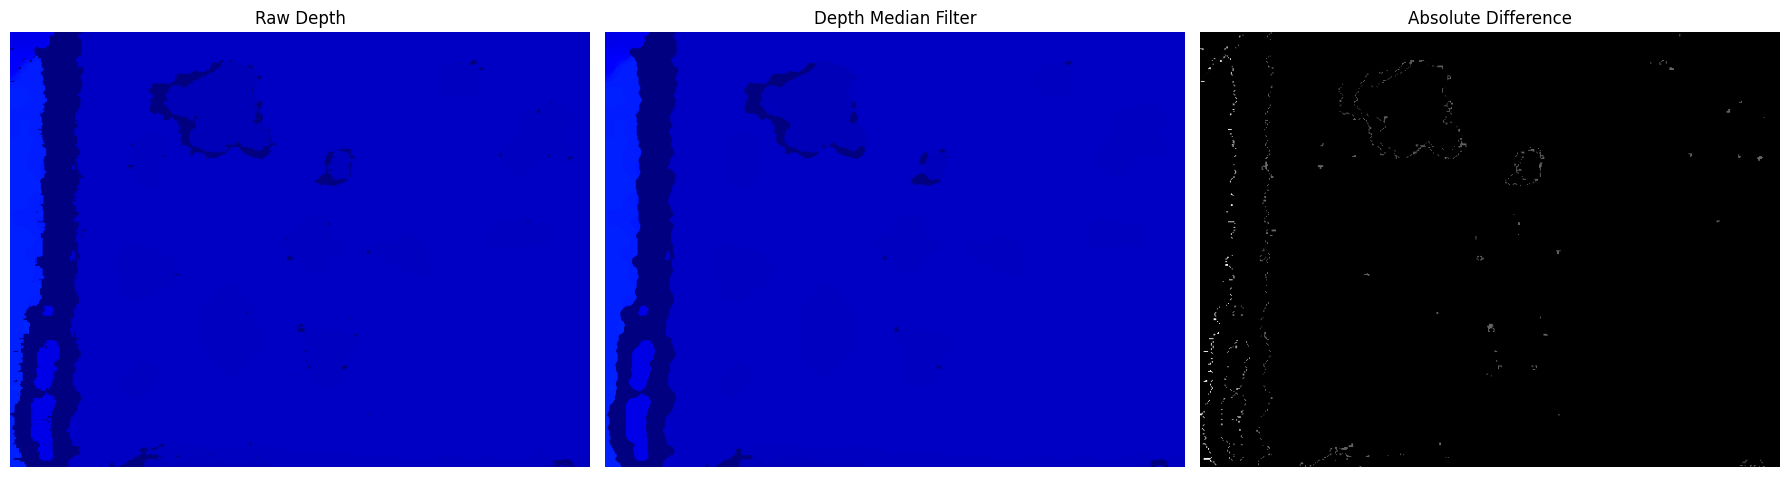


[필터 적용 결과 통계]
{'ksize': 5,
 'hole_filled': True,
 'before_median_mm': 572.0,
 'before_mean_mm': 599.3591522239493,
 'before_std_mm': 154.16106635018375,
 'after_median_mm': 572.0,
 'after_mean_mm': 598.3853729375729,
 'after_std_mm': 155.1483065494835}


In [344]:
valid_mask = (depth_img > 0).astype(np.uint8)

depth_filtered, depth_filter_info = apply_depth_median_filter(
    depth_img=depth_img,
    ksize=5,
    valid_mask=valid_mask,
    fill_holes=True, # 엣지 파먹힘 방지 ON
    show=True        # 시각화 ON
)

print("\n[필터 적용 결과 통계]")
pprint.pprint(depth_filter_info, sort_dicts=False)

# **메디안 필터를 이용한 훅 꺾이는 배경 검출**

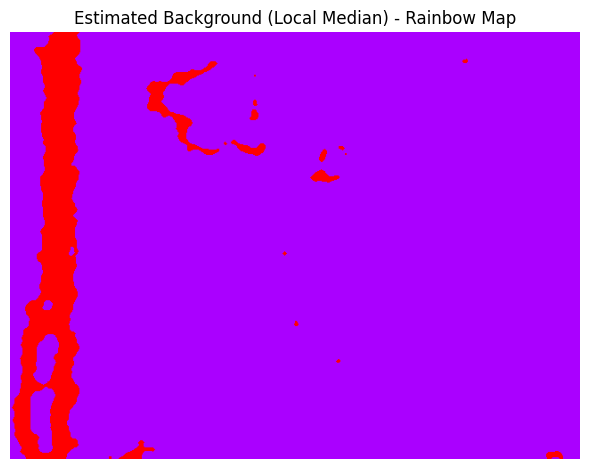

In [345]:
# 1. 계산된 local median map (배경)을 mm 단위로 가져옵니다.
local_median_mm = depth_filtered.astype(np.float32)
valid_values = (depth_img > 0).astype(np.uint8)

# 2. valid depth 영역에 대해서만 percentile 기반으로 스케일링하여
# 보기 좋게 시각화할 수 있도록 uint8로 변환합니다.
# (타겟 물체들이 있는 깊이 범위로 클리핑합니다.)
p05 = np.percentile(valid_values, 5) if valid_values.size > 0 else 0
p95 = np.percentile(valid_values, 95) if valid_values.size > 0 else 1.0 # 0 division 방지

median_clip = np.clip(local_median_mm, p05, p95)
median_norm = ((median_clip - p05) / max(p95 - p05, 1e-6) * 255).astype(np.uint8)

# 3. OpenCV의 COLORMAP_RAINBOW를 적용합니다. (사용자 요청)
median_rainbow = cv2.applyColorMap(median_norm, cv2.COLORMAP_RAINBOW)
median_rainbow_rgb = cv2.cvtColor(median_rainbow, cv2.COLOR_BGR2RGB)

# 4. matplotlib를 이용해 시각화합니다.
fig, axes = plt.subplots(1, 1, figsize=(6, 5))
axes.imshow(median_rainbow_rgb)
axes.set_title("Estimated Background (Local Median) - Rainbow Map")
axes.axis("off")
plt.tight_layout()
plt.show()

# **Local Protrusion Depth Mask**

주변 local median depth와 현재 depth를 비교해서, 주변보다 카메라 쪽으로 튀어나온 영역을 검출한다.
절대적으로 가까운 물체만 잡는 방식이 아니라, 뒤쪽에 있어도 주변보다 돌출된 알맹이를 잡는 데 사용한다.

In [346]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

def create_local_protrusion_depth_mask(
    depth_img,
    valid_mask=None,
    depth_scale=0.001,
    local_kernel=51,
    protrusion_threshold_mm=20.0,
    
    # 🔥 [추가] 허공 방어 로직 파라미터
    max_protrusion_mm=100.0,         # 너무 높게 튀어나온 곳(절벽 모서리 등) 무시
    max_background_depth_mm=1000.0,  # 너무 먼 바닥(허공)에서 발생한 돌출 무시
    
    min_area=50,
    max_area_ratio=0.35,
    close_kernel=7,
    open_kernel=3,
    ignore_border_touching=True,
    border_margin=3,
    show=False,
    title="Local Protrusion Depth Mask"
):
    """
    주변 local median depth보다 카메라 쪽으로 튀어나온 영역을 검출한다.
    (추가: 책상 모서리나 먼 바닥에서 발생하는 가짜 돌출 방지 로직 포함)
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")
    if not isinstance(depth_img, np.ndarray):
        raise TypeError("depth_img는 np.ndarray 형식이어야 합니다.")
    if depth_img.ndim != 2:
        raise ValueError(f"depth_img는 2D여야 합니다. 현재 shape: {depth_img.shape}")
    if local_kernel % 2 == 0 or local_kernel < 3:
        raise ValueError("local_kernel은 최소 3 이상의 홀수여야 합니다. 예: 31, 51, 71")

    h, w = depth_img.shape
    image_area = h * w
    depth_mm = depth_img.astype(np.float32) * float(depth_scale) * 1000.0

    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    valid_values = depth_mm[valid_bool]

    if valid_values.size == 0:
        print("[WARN] valid depth가 없어 local protrusion mask를 만들 수 없습니다.")
        return np.zeros_like(depth_img, dtype=np.uint8), {
            "component_count": 0,
            "components": [],
        }

    # invalid 영역은 local median 계산을 망치지 않도록 먼 거리값으로 임시 대체
    far_value = float(np.percentile(valid_values, 95))
    depth_for_median = depth_mm.copy()
    depth_for_median[~valid_bool] = far_value

    try:
        from scipy.ndimage import median_filter
        local_median = median_filter(depth_for_median, size=local_kernel)
        local_stat_method = "scipy.ndimage.median_filter"
    except ImportError:
        print("[WARN] scipy가 없어 cv2.blur로 local mean을 대신 사용합니다.")
        local_median = cv2.blur(depth_for_median, (local_kernel, local_kernel))
        local_stat_method = "cv2.blur_local_mean"

    # ------------------------------------------------------------
    # 🔥 [핵심 방어 로직] 
    # ------------------------------------------------------------
    protrusion_mm = local_median - depth_mm

    # 1. threshold 이상 튀어나올 것
    protrusion_bool = valid_bool & (protrusion_mm >= float(protrusion_threshold_mm))

    # 2. 책상 모서리 방어: 듀플로 블록 최대 높이보다 더 튀어나왔으면 탈락!
    if max_protrusion_mm is not None:
        protrusion_bool &= (protrusion_mm <= float(max_protrusion_mm))

    # 3. 심해 방어: 물체가 깔려있는 바닥(local_median)이 너무 멀면 탈락!
    if max_background_depth_mm is not None:
        protrusion_bool &= (local_median <= float(max_background_depth_mm))

    protrusion_mask = protrusion_bool.astype(np.uint8) * 255

    # morphology 정리
    if close_kernel is not None and close_kernel > 0:
        k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_kernel, close_kernel))
        protrusion_mask = cv2.morphologyEx(protrusion_mask, cv2.MORPH_CLOSE, k_close, iterations=1)

    if open_kernel is not None and open_kernel > 0:
        k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_kernel, open_kernel))
        protrusion_mask = cv2.morphologyEx(protrusion_mask, cv2.MORPH_OPEN, k_open, iterations=1)

    # component filtering
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(protrusion_mask, connectivity=8)

    cleaned = np.zeros_like(protrusion_mask)
    components = []

    for label_id in range(1, num_labels):
        area = int(stats[label_id, cv2.CC_STAT_AREA])
        area_ratio = area / max(image_area, 1)

        if area < min_area or area_ratio > max_area_ratio:
            continue

        x = int(stats[label_id, cv2.CC_STAT_LEFT])
        y = int(stats[label_id, cv2.CC_STAT_TOP])
        bw = int(stats[label_id, cv2.CC_STAT_WIDTH])
        bh = int(stats[label_id, cv2.CC_STAT_HEIGHT])

        if ignore_border_touching:
            touches_border = (
                x <= border_margin or y <= border_margin or
                x + bw >= w - border_margin or y + bh >= h - border_margin
            )
            if touches_border:
                continue

        comp_mask = labels == label_id
        comp_depth = depth_mm[comp_mask & valid_bool]
        comp_protrusion = protrusion_mm[comp_mask & valid_bool]

        if comp_depth.size == 0:
            continue

        cx, cy = centroids[label_id]
        cleaned[comp_mask] = 255

        components.append({
            "label_id": int(label_id),
            "area": area,
            "area_ratio": float(area_ratio),
            "bbox": [x, y, bw, bh],
            "centroid": [float(cx), float(cy)],
            "depth_median_mm": float(np.median(comp_depth)),
            "depth_std_mm": float(np.std(comp_depth)),
            "protrusion_median_mm": float(np.median(comp_protrusion)),
            "protrusion_mean_mm": float(np.mean(comp_protrusion)),
        })

    protrusion_mask = cleaned

    print("\n[LOCAL PROTRUSION DEPTH MASK]")
    print(f"local method            : {local_stat_method}")
    print(f"local_kernel            : {local_kernel}")
    print(f"protrusion_threshold_mm : {protrusion_threshold_mm:.2f}")
    print(f"max_protrusion_mm       : {max_protrusion_mm}")
    print(f"max_background_depth_mm : {max_background_depth_mm}")
    print(f"detected components     : {len(components)}")

    for i, comp in enumerate(components):
        print(
            f"  - comp {i}: area={comp['area']}, bbox={comp['bbox']}, "
            f"depth_median={comp['depth_median_mm']:.2f} mm, "
            f"protrusion_median={comp['protrusion_median_mm']:.2f} mm"
        )

    protrusion_info = {
        "local_method": local_stat_method,
        "local_kernel": int(local_kernel),
        "protrusion_threshold_mm": float(protrusion_threshold_mm),
        "max_protrusion_mm": max_protrusion_mm,
        "max_background_depth_mm": max_background_depth_mm,
        "component_count": len(components),
        "components": components,
    }

    if show:
        valid_protrusion = protrusion_mm[valid_bool]
        upper = np.percentile(valid_protrusion, 99) if valid_protrusion.size > 0 else 1.0

        protrusion_vis = protrusion_mm.copy()
        protrusion_vis[~valid_bool] = 0
        protrusion_vis = np.clip(protrusion_vis, 0, upper)

        protrusion_norm = cv2.normalize(protrusion_vis, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        protrusion_color = cv2.applyColorMap(protrusion_norm, cv2.COLORMAP_JET)
        protrusion_color = cv2.cvtColor(protrusion_color, cv2.COLOR_BGR2RGB)

        overlay = protrusion_color.copy()
        red = np.zeros_like(overlay)
        red[:, :, 0] = 255

        mask_bool = protrusion_mask > 0
        overlay[mask_bool] = (0.55 * overlay[mask_bool] + 0.45 * red[mask_bool]).astype(np.uint8)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].imshow(protrusion_color)
        axes[0].set_title("Local Protrusion Map")
        axes[0].axis("off")

        axes[1].imshow(protrusion_mask, cmap="gray")
        axes[1].set_title(title)
        axes[1].axis("off")

        axes[2].imshow(overlay)
        axes[2].set_title("Protrusion Overlay")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

    return protrusion_mask, protrusion_info


[LOCAL PROTRUSION DEPTH MASK]
local method            : scipy.ndimage.median_filter
local_kernel            : 51
protrusion_threshold_mm : 5.00
max_protrusion_mm       : 100.0
max_background_depth_mm : 1200.0
detected components     : 43
  - comp 0: area=1460, bbox=[387, 26, 50, 39], depth_median=558.00 mm, protrusion_median=8.00 mm
  - comp 1: area=2548, bbox=[462, 26, 63, 53], depth_median=549.00 mm, protrusion_median=9.00 mm
  - comp 2: area=136, bbox=[205, 33, 18, 11], depth_median=564.00 mm, protrusion_median=7.00 mm
  - comp 3: area=323, bbox=[232, 32, 42, 28], depth_median=479.00 mm, protrusion_median=90.00 mm
  - comp 4: area=397, bbox=[170, 59, 21, 33], depth_median=479.00 mm, protrusion_median=91.00 mm
  - comp 5: area=845, bbox=[589, 69, 37, 35], depth_median=548.00 mm, protrusion_median=9.00 mm
  - comp 6: area=484, bbox=[551, 79, 27, 25], depth_median=551.00 mm, protrusion_median=8.00 mm
  - comp 7: area=2700, bbox=[124, 99, 66, 82], depth_median=550.00 mm, protrusion_med

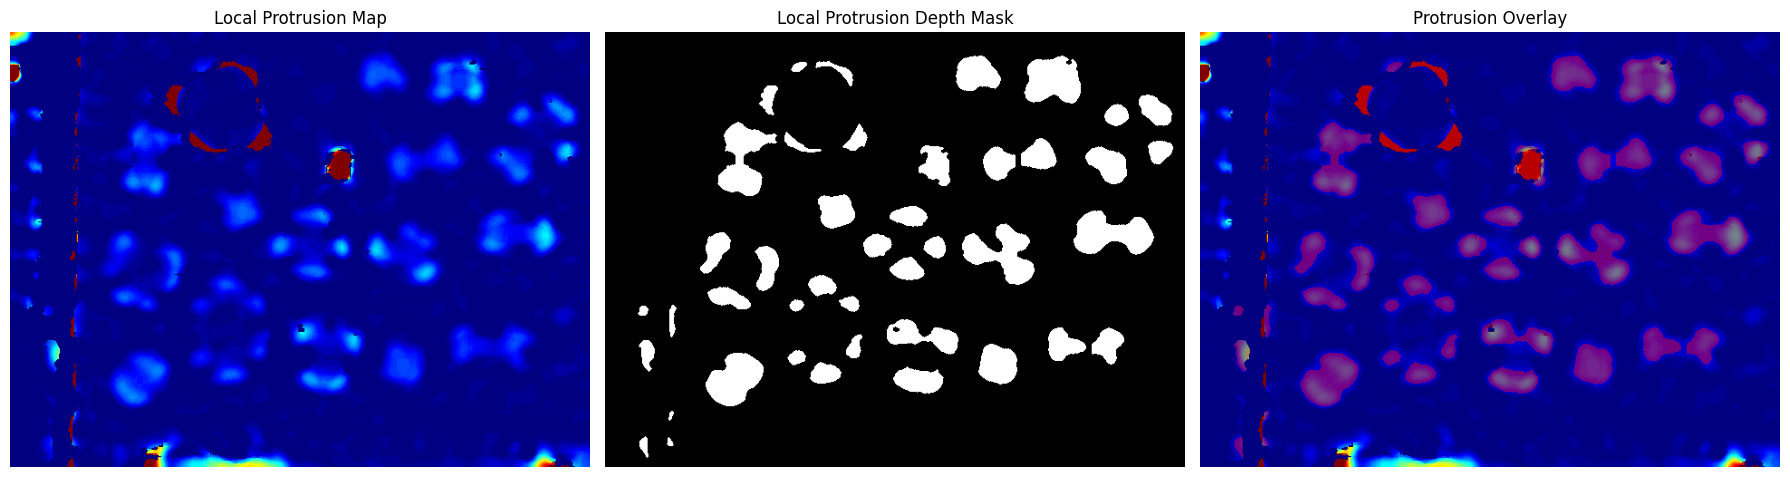

{'local_method': 'scipy.ndimage.median_filter', 'local_kernel': 51, 'protrusion_threshold_mm': 5.0, 'max_protrusion_mm': 100.0, 'max_background_depth_mm': 1200.0, 'component_count': 43, 'components': [{'label_id': 2, 'area': 1460, 'area_ratio': 0.004752604166666666, 'bbox': [387, 26, 50, 39], 'centroid': [409.6595890410959, 45.87123287671233], 'depth_median_mm': 558.0, 'depth_std_mm': 3.82326078414917, 'protrusion_median_mm': 8.00006103515625, 'protrusion_mean_mm': 8.240407943725586}, {'label_id': 3, 'area': 2548, 'area_ratio': 0.008294270833333334, 'bbox': [462, 26, 63, 53], 'centroid': [494.0031397174254, 52.84850863422292], 'depth_median_mm': 549.0, 'depth_std_mm': 7.821446895599365, 'protrusion_median_mm': 9.00006103515625, 'protrusion_mean_mm': 9.897668838500977}, {'label_id': 5, 'area': 136, 'area_ratio': 0.0004427083333333333, 'bbox': [205, 33, 18, 11], 'centroid': [213.5441176470588, 37.88235294117647], 'depth_median_mm': 564.0, 'depth_std_mm': 1.442566990852356, 'protrusion_me

In [347]:
local_protrusion_mask, local_protrusion_info = create_local_protrusion_depth_mask(
    depth_img=depth_filtered,
    valid_mask=valid_mask,
    depth_scale=intrinsics["depth"]["depth_scale"],

    # 1. 주변 비교 범위 (타겟 객체보다 1.5배 정도 큰 홀수)
    # 만약 원형 용기 내부의 물체를 잡는 거라면 용기 크기보다 작아야 합니다. 
    # 현재 51도 나쁘지 않아 보입니다.
    local_kernel=51,

    # 🔥 2. [수정] 타겟 검출 하한선 낮추기
    # 파란색 덩어리들도 잡힐 수 있도록 커트라인을 대폭 낮춥니다. (예: 5mm ~ 8mm)
    protrusion_threshold_mm=5.0, 

    # 🔥 3. [추가] 낭떠러지 & 거대 테두리 방어선 (이전 코드의 핵심!)
    # 타겟 객체의 최대 높이가 20mm를 넘지 않는다면, 30mm 이상 튀어나온 
    # 빨간색 낭떠러지와 원형 테두리는 전부 가짜(배경)로 간주하고 무시합니다.
    max_protrusion_mm=100.0, 

    # (옵션) 허공/바닥 방어 로직이 필요하다면 추가
    max_background_depth_mm=1200.0,

    min_area=30,           # 객체 크기가 작으므로 최소 면적도 살짝 낮춰줍니다.
    max_area_ratio=0.35,

    close_kernel=5,        # 타겟이 작으므로 모폴로지도 살짝 줄입니다.
    open_kernel=3,

    ignore_border_touching=True,
    border_margin=5,       # 왼쪽 낭떠러지가 화면 끝에 걸쳐있다면 여유를 더 줍니다.

    show=True
)

print(local_protrusion_info)

# **Depth Gradient Barrier Mask**

depth_img에서 값이 급격히 변하는 지점을 찾아 공간상 경계선으로 사용하는 함수다.
객체 후보가 배경이나 훅 꺼진 공간으로 번지는 것을 막기 위한 barrier mask로 사용한다.

In [348]:
def create_depth_gradient_barrier_mask(
    depth_img,
    valid_mask=None,
    depth_scale=0.001,
    grad_threshold_mm=35.0,
    blur_ksize=3,
    dilate_kernel=3,
    show=False,
    title="Depth Gradient Barrier Mask"
):
    """
    depth gradient가 큰 위치를 barrier mask로 생성한다.

    객체와 배경 사이, 또는 공간상에서 훅 꺾이는 부분은 depth 변화량이 크므로
    이를 region growing이나 candidate mask 확장 제한선으로 사용할 수 있다.

    Parameters
    ----------
    depth_img : np.ndarray
        RealSense aligned depth image.

    valid_mask : np.ndarray or None
        유효 depth mask.
        None이면 depth_img > 0 기준으로 사용한다.

    depth_scale : float
        RealSense depth scale.
        기본 0.001이면 raw depth 1000 = 1000 mm.

    grad_threshold_mm : float
        gradient magnitude threshold.
        낮으면 barrier가 많이 생기고, 높으면 강한 경계만 남는다.

    blur_ksize : int
        gradient 계산 전 depth를 약하게 smoothing할 kernel size.
        0 또는 None이면 blur 생략.

    dilate_kernel : int
        barrier를 두껍게 만들기 위한 dilation kernel size.
        0 또는 None이면 생략.

    show : bool
        True이면 결과를 시각화한다.

    title : str
        시각화 제목.

    Returns
    -------
    barrier_mask : np.ndarray
        depth gradient barrier mask.
        dtype=np.uint8, 값은 0 또는 255.

    barrier_info : dict
        gradient 통계와 threshold 정보.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if not isinstance(depth_img, np.ndarray):
        raise TypeError("depth_img는 np.ndarray 형식이어야 합니다.")

    if depth_img.ndim != 2:
        raise ValueError(f"depth_img는 2D여야 합니다. 현재 shape: {depth_img.shape}")

    depth_mm = depth_img.astype(np.float32) * float(depth_scale) * 1000.0

    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    valid_count = int(np.count_nonzero(valid_bool))

    if valid_count == 0:
        print("[WARN] valid depth가 없어 gradient barrier를 만들 수 없습니다.")
        return np.zeros_like(depth_img, dtype=np.uint8), {
            "grad_threshold_mm": float(grad_threshold_mm),
            "barrier_pixels": 0,
            "valid_count": 0,
        }

    valid_values = depth_mm[valid_bool]
    median_depth = float(np.median(valid_values))

    # invalid 영역은 median으로 임시 대체해서 Sobel 계산 시 큰 튐을 줄임
    depth_for_grad = depth_mm.copy()
    depth_for_grad[~valid_bool] = median_depth

    if blur_ksize is not None and blur_ksize > 0:
        if blur_ksize % 2 == 0:
            raise ValueError("blur_ksize는 홀수여야 합니다. 예: 3, 5, 7")
        depth_for_grad = cv2.GaussianBlur(
            depth_for_grad,
            (blur_ksize, blur_ksize),
            0
        )

    gx = cv2.Sobel(depth_for_grad, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(depth_for_grad, cv2.CV_32F, 0, 1, ksize=3)

    grad_mag = np.sqrt(gx * gx + gy * gy)

    barrier_bool = valid_bool & (grad_mag >= float(grad_threshold_mm))
    barrier_mask = barrier_bool.astype(np.uint8) * 255

    if dilate_kernel is not None and dilate_kernel > 0:
        k_dilate = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (dilate_kernel, dilate_kernel)
        )
        barrier_mask = cv2.dilate(barrier_mask, k_dilate, iterations=1)

    valid_grad = grad_mag[valid_bool]

    grad_p50 = float(np.percentile(valid_grad, 50))
    grad_p90 = float(np.percentile(valid_grad, 90))
    grad_p95 = float(np.percentile(valid_grad, 95))
    grad_p99 = float(np.percentile(valid_grad, 99))

    barrier_pixels = int(np.count_nonzero(barrier_mask))

    print("\n[DEPTH GRADIENT BARRIER MASK]")
    print(f"valid count          : {valid_count}")
    print(f"grad_threshold_mm    : {grad_threshold_mm:.2f}")
    print(f"barrier pixels       : {barrier_pixels}")
    print(f"grad p50/p90/p95/p99 : {grad_p50:.2f} / {grad_p90:.2f} / {grad_p95:.2f} / {grad_p99:.2f}")

    barrier_info = {
        "valid_count": valid_count,
        "grad_threshold_mm": float(grad_threshold_mm),
        "barrier_pixels": barrier_pixels,
        "grad_p50": grad_p50,
        "grad_p90": grad_p90,
        "grad_p95": grad_p95,
        "grad_p99": grad_p99,
        "blur_ksize": blur_ksize,
        "dilate_kernel": dilate_kernel,
    }

    if show:
        grad_clip = np.clip(grad_mag, 0, grad_p99)
        grad_norm = cv2.normalize(
            grad_clip,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        grad_color = cv2.applyColorMap(grad_norm, cv2.COLORMAP_JET)
        grad_color = cv2.cvtColor(grad_color, cv2.COLOR_BGR2RGB)

        overlay = grad_color.copy()
        red = np.zeros_like(overlay)
        red[:, :, 0] = 255

        mask_bool = barrier_mask > 0
        overlay[mask_bool] = (
            0.55 * overlay[mask_bool] + 0.45 * red[mask_bool]
        ).astype(np.uint8)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].imshow(grad_color)
        axes[0].set_title("Depth Gradient Magnitude")
        axes[0].axis("off")

        axes[1].imshow(barrier_mask, cmap="gray")
        axes[1].set_title(title)
        axes[1].axis("off")

        axes[2].imshow(overlay)
        axes[2].set_title("Barrier Overlay")
        axes[2].axis("off")

        plt.tight_layout()
        plt.show()

    return barrier_mask, barrier_info


[DEPTH GRADIENT BARRIER MASK]
valid count          : 283348
grad_threshold_mm    : 8.00
barrier pixels       : 68091
grad p50/p90/p95/p99 : 2.49 / 11.93 / 14.95 / 212.22


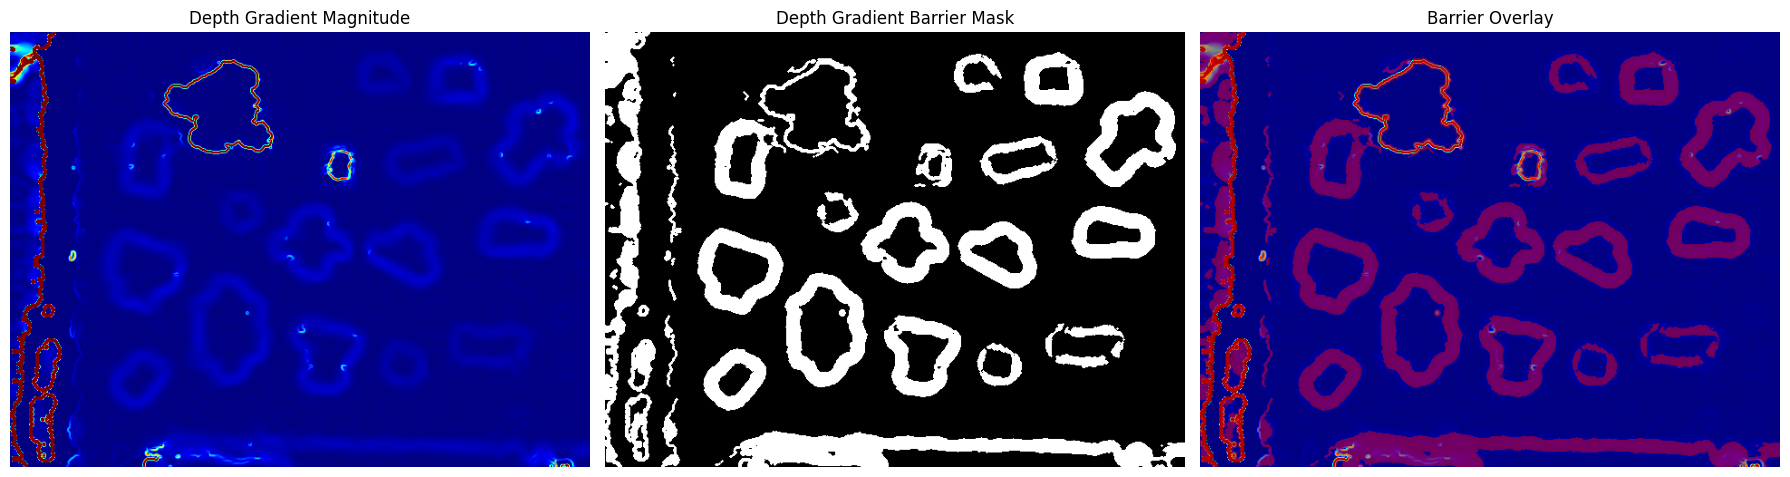

{'valid_count': 283348, 'grad_threshold_mm': 8.0, 'barrier_pixels': 68091, 'grad_p50': 2.490607261657715, 'grad_p90': 11.932427406311035, 'grad_p95': 14.946257591247559, 'grad_p99': 212.2227317810041, 'blur_ksize': 3, 'dilate_kernel': 3}


In [349]:
depth_barrier_mask,depth_barrier_info = create_depth_gradient_barrier_mask(
    depth_img=depth_filtered,
    valid_mask=valid_mask,
    depth_scale=intrinsics["depth"]["depth_scale"],

    grad_threshold_mm=8.0,
    blur_ksize=3,
    dilate_kernel=3,

    show=True
)

print(depth_barrier_info)

# **Depth Gradient Component Mask**

Depth gradient가 큰 부분을 경계선으로 보고, 그 경계를 제외한 valid depth 영역에서 connected component를 찾는 함수다.
고정된 60mm depth 차이에 의존하지 않고, 공간상에서 깊이 변화가 급격한 경계를 기준으로 덩어리 후보를 분리한다

In [350]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt


def create_depth_gradient_component_mask(
    depth_img,
    valid_mask=None,
    depth_scale=0.001,
    grad_threshold_mode="percentile",
    grad_threshold_mm=35.0,
    grad_percentile=92.0,
    blur_ksize=3,
    barrier_dilate_kernel=3,
    min_area=40,
    max_area_ratio=0.35,
    max_component_depth_std_mm=120.0,
    ignore_border_touching=True,
    border_margin=3,
    close_kernel=5,
    open_kernel=3,
    show=False,
    title="Depth Gradient Component Mask"
):
    """
    Depth gradient를 barrier로 사용하여 valid depth 영역을 component로 분리한다.

    절대 depth 차이가 몇 mm 이상인지가 아니라,
    depth가 급격히 바뀌는 경계선을 기준으로 영역을 나눈다.

    Parameters
    ----------
    depth_img : np.ndarray
        RealSense aligned depth image.

    valid_mask : np.ndarray or None
        유효 depth mask. None이면 depth_img > 0 기준.

    depth_scale : float
        RealSense depth scale.
        기본 0.001이면 raw depth 1000 = 1000 mm.

    grad_threshold_mode : str
        "percentile" 또는 "absolute".
        percentile이면 gradient 상위 grad_percentile 기준으로 barrier 생성.
        absolute이면 grad_threshold_mm 기준으로 barrier 생성.

    grad_threshold_mm : float
        absolute mode에서 사용할 gradient threshold.

    grad_percentile : float
        percentile mode에서 사용할 gradient percentile.
        예: 92이면 gradient 상위 8%를 barrier로 사용.

    blur_ksize : int
        gradient 계산 전 depth smoothing kernel size.
        0 또는 None이면 blur 생략.

    barrier_dilate_kernel : int
        barrier를 두껍게 만들기 위한 dilation kernel size.
        0 또는 None이면 생략.

    min_area : int
        component 최소 면적.

    max_area_ratio : float
        화면 전체 대비 component 최대 면적 비율.
        너무 큰 영역은 배경/바닥일 가능성이 높으므로 제거.

    max_component_depth_std_mm : float
        component 내부 depth 표준편차 허용값.
        너무 크면 여러 표면/공간이 섞인 영역으로 보고 제거.

    ignore_border_touching : bool
        이미지 경계에 닿은 component를 제거할지 여부.

    border_margin : int
        경계 접촉 판정 여유 픽셀.

    close_kernel : int
        최종 component mask closing kernel size.

    open_kernel : int
        최종 component mask opening kernel size.

    show : bool
        True이면 결과 시각화.

    title : str
        시각화 제목.

    Returns
    -------
    component_mask : np.ndarray
        gradient barrier 기준으로 분리된 depth component mask.
        dtype=np.uint8, 값은 0 또는 255.

    component_info : dict
        gradient threshold, component 정보 등 디버깅 정보.
    """

    if depth_img is None:
        raise ValueError("depth_img가 None입니다.")

    if not isinstance(depth_img, np.ndarray):
        raise TypeError("depth_img는 np.ndarray 형식이어야 합니다.")

    if depth_img.ndim != 2:
        raise ValueError(f"depth_img는 2D여야 합니다. 현재 shape: {depth_img.shape}")

    if grad_threshold_mode not in ["percentile", "absolute"]:
        raise ValueError("grad_threshold_mode는 'percentile' 또는 'absolute'여야 합니다.")

    h, w = depth_img.shape
    image_area = h * w

    depth_mm = depth_img.astype(np.float32) * float(depth_scale) * 1000.0

    if valid_mask is None:
        valid_bool = depth_img > 0
    else:
        if valid_mask.shape != depth_img.shape:
            raise ValueError("valid_mask와 depth_img의 shape가 다릅니다.")
        valid_bool = (valid_mask > 0) & (depth_img > 0)

    valid_count = int(np.count_nonzero(valid_bool))

    if valid_count == 0:
        print("[WARN] valid depth가 없어 gradient component mask를 만들 수 없습니다.")
        return np.zeros_like(depth_img, dtype=np.uint8), {
            "component_count": 0,
            "components": [],
            "valid_count": 0,
        }

    valid_values = depth_mm[valid_bool]
    median_depth = float(np.median(valid_values))

    # invalid 영역은 median으로 대체해서 Sobel 계산 시 invalid 경계가 과도하게 튀는 것을 줄임
    depth_for_grad = depth_mm.copy()
    depth_for_grad[~valid_bool] = median_depth

    if blur_ksize is not None and blur_ksize > 0:
        if blur_ksize % 2 == 0:
            raise ValueError("blur_ksize는 홀수여야 합니다. 예: 3, 5, 7")
        depth_for_grad = cv2.GaussianBlur(
            depth_for_grad,
            (blur_ksize, blur_ksize),
            0
        )

    # depth gradient 계산
    gx = cv2.Sobel(depth_for_grad, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(depth_for_grad, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = np.sqrt(gx * gx + gy * gy)

    valid_grad = grad_mag[valid_bool]

    grad_p50 = float(np.percentile(valid_grad, 50))
    grad_p90 = float(np.percentile(valid_grad, 90))
    grad_p92 = float(np.percentile(valid_grad, 92))
    grad_p95 = float(np.percentile(valid_grad, 95))
    grad_p99 = float(np.percentile(valid_grad, 99))

    if grad_threshold_mode == "percentile":
        grad_threshold_used = float(np.percentile(valid_grad, grad_percentile))
    else:
        grad_threshold_used = float(grad_threshold_mm)

    # depth 변화가 큰 부분을 barrier로 설정
    barrier_bool = valid_bool & (grad_mag >= grad_threshold_used)
    barrier_mask = barrier_bool.astype(np.uint8) * 255

    if barrier_dilate_kernel is not None and barrier_dilate_kernel > 0:
        k_barrier = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (barrier_dilate_kernel, barrier_dilate_kernel)
        )
        barrier_mask = cv2.dilate(barrier_mask, k_barrier, iterations=1)

    # valid 영역에서 barrier를 제외한 영역을 component 후보로 사용
    valid_uint8 = valid_bool.astype(np.uint8) * 255
    non_barrier_mask = cv2.bitwise_and(
        valid_uint8,
        cv2.bitwise_not(barrier_mask)
    )

    # 약간 정리
    if close_kernel is not None and close_kernel > 0:
        k_close = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (close_kernel, close_kernel)
        )
        non_barrier_mask = cv2.morphologyEx(
            non_barrier_mask,
            cv2.MORPH_CLOSE,
            k_close,
            iterations=1
        )

    if open_kernel is not None and open_kernel > 0:
        k_open = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (open_kernel, open_kernel)
        )
        non_barrier_mask = cv2.morphologyEx(
            non_barrier_mask,
            cv2.MORPH_OPEN,
            k_open,
            iterations=1
        )

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        non_barrier_mask,
        connectivity=8
    )

    component_mask = np.zeros_like(non_barrier_mask)
    components = []

    for label_id in range(1, num_labels):
        area = int(stats[label_id, cv2.CC_STAT_AREA])
        area_ratio = area / max(image_area, 1)

        if area < min_area:
            continue

        if area_ratio > max_area_ratio:
            continue

        x = int(stats[label_id, cv2.CC_STAT_LEFT])
        y = int(stats[label_id, cv2.CC_STAT_TOP])
        bw = int(stats[label_id, cv2.CC_STAT_WIDTH])
        bh = int(stats[label_id, cv2.CC_STAT_HEIGHT])

        if ignore_border_touching:
            touches_border = (
                x <= border_margin or
                y <= border_margin or
                x + bw >= w - border_margin or
                y + bh >= h - border_margin
            )

            if touches_border:
                continue

        comp_mask = labels == label_id
        comp_valid = comp_mask & valid_bool
        comp_depth = depth_mm[comp_valid]
        comp_grad = grad_mag[comp_valid]

        if comp_depth.size == 0:
            continue

        comp_depth_std = float(np.std(comp_depth))

        if comp_depth_std > max_component_depth_std_mm:
            continue

        cx, cy = centroids[label_id]

        component_mask[comp_mask] = 255

        components.append({
            "label_id": int(label_id),
            "area": area,
            "area_ratio": float(area_ratio),
            "bbox": [x, y, bw, bh],
            "centroid": [float(cx), float(cy)],
            "depth_median_mm": float(np.median(comp_depth)),
            "depth_mean_mm": float(np.mean(comp_depth)),
            "depth_std_mm": comp_depth_std,
            "depth_min_mm": float(np.min(comp_depth)),
            "depth_max_mm": float(np.max(comp_depth)),
            "grad_mean": float(np.mean(comp_grad)),
            "grad_median": float(np.median(comp_grad)),
        })

    print("\n[DEPTH GRADIENT COMPONENT MASK]")
    print(f"valid count              : {valid_count}")
    print(f"threshold mode           : {grad_threshold_mode}")
    print(f"grad threshold used      : {grad_threshold_used:.2f}")
    print(f"grad p50/p90/p92/p95/p99 : {grad_p50:.2f} / {grad_p90:.2f} / {grad_p92:.2f} / {grad_p95:.2f} / {grad_p99:.2f}")
    print(f"detected components      : {len(components)}")

    for i, comp in enumerate(components):
        print(
            f"  - comp {i}: "
            f"area={comp['area']}, "
            f"bbox={comp['bbox']}, "
            f"depth_median={comp['depth_median_mm']:.2f} mm, "
            f"depth_std={comp['depth_std_mm']:.2f} mm"
        )

    component_info = {
        "valid_count": valid_count,
        "grad_threshold_mode": grad_threshold_mode,
        "grad_threshold_used": grad_threshold_used,
        "grad_percentile": float(grad_percentile),
        "grad_threshold_mm": float(grad_threshold_mm),
        "grad_p50": grad_p50,
        "grad_p90": grad_p90,
        "grad_p92": grad_p92,
        "grad_p95": grad_p95,
        "grad_p99": grad_p99,
        "component_count": len(components),
        "components": components,
    }

    if show:
        # gradient 시각화
        grad_clip = np.clip(grad_mag, 0, grad_p99)
        grad_norm = cv2.normalize(
            grad_clip,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        grad_color = cv2.applyColorMap(grad_norm, cv2.COLORMAP_JET)
        grad_color = cv2.cvtColor(grad_color, cv2.COLOR_BGR2RGB)

        # depth view
        p05 = np.percentile(valid_values, 5)
        p95 = np.percentile(valid_values, 95)
        depth_clip = np.clip(depth_mm, p05, p95)
        depth_norm = ((depth_clip - p05) / max(p95 - p05, 1e-6) * 255).astype(np.uint8)
        depth_norm[~valid_bool] = 0
        depth_color = cv2.applyColorMap(depth_norm, cv2.COLORMAP_JET)
        depth_color = cv2.cvtColor(depth_color, cv2.COLOR_BGR2RGB)

        # component overlay
        overlay = depth_color.copy()
        red = np.zeros_like(overlay)
        red[:, :, 0] = 255

        comp_bool = component_mask > 0
        overlay[comp_bool] = (
            0.55 * overlay[comp_bool] + 0.45 * red[comp_bool]
        ).astype(np.uint8)

        fig, axes = plt.subplots(1, 4, figsize=(22, 5))

        axes[0].imshow(grad_color)
        axes[0].set_title("Depth Gradient Magnitude")
        axes[0].axis("off")

        axes[1].imshow(barrier_mask, cmap="gray")
        axes[1].set_title("Gradient Barrier")
        axes[1].axis("off")

        axes[2].imshow(component_mask, cmap="gray")
        axes[2].set_title(title)
        axes[2].axis("off")

        axes[3].imshow(overlay)
        axes[3].set_title("Component Overlay")
        axes[3].axis("off")

        plt.tight_layout()
        plt.show()

    return component_mask, component_info


[DEPTH GRADIENT COMPONENT MASK]
valid count              : 283348
threshold mode           : percentile
grad threshold used      : 4.40
grad p50/p90/p92/p95/p99 : 2.49 / 11.93 / 12.85 / 14.95 / 212.22
detected components      : 20
  - comp 0: area=5871, bbox=[176, 36, 109, 94], depth_median=478.00 mm, depth_std=0.94 mm
  - comp 1: area=287, bbox=[398, 37, 25, 17], depth_median=553.00 mm, depth_std=0.58 mm
  - comp 2: area=525, bbox=[482, 40, 28, 22], depth_median=541.00 mm, depth_std=0.80 mm
  - comp 3: area=1821, bbox=[550, 85, 61, 65], depth_median=540.00 mm, depth_std=0.85 mm
  - comp 4: area=46, bbox=[175, 95, 9, 9], depth_median=571.00 mm, depth_std=0.58 mm
  - comp 5: area=850, bbox=[139, 116, 27, 50], depth_median=544.00 mm, depth_std=1.22 mm
  - comp 6: area=771, bbox=[429, 129, 57, 25], depth_median=553.00 mm, depth_std=0.61 mm
  - comp 7: area=244, bbox=[357, 136, 14, 23], depth_median=511.00 mm, depth_std=0.82 mm
  - comp 8: area=243, bbox=[246, 190, 20, 16], depth_median=5

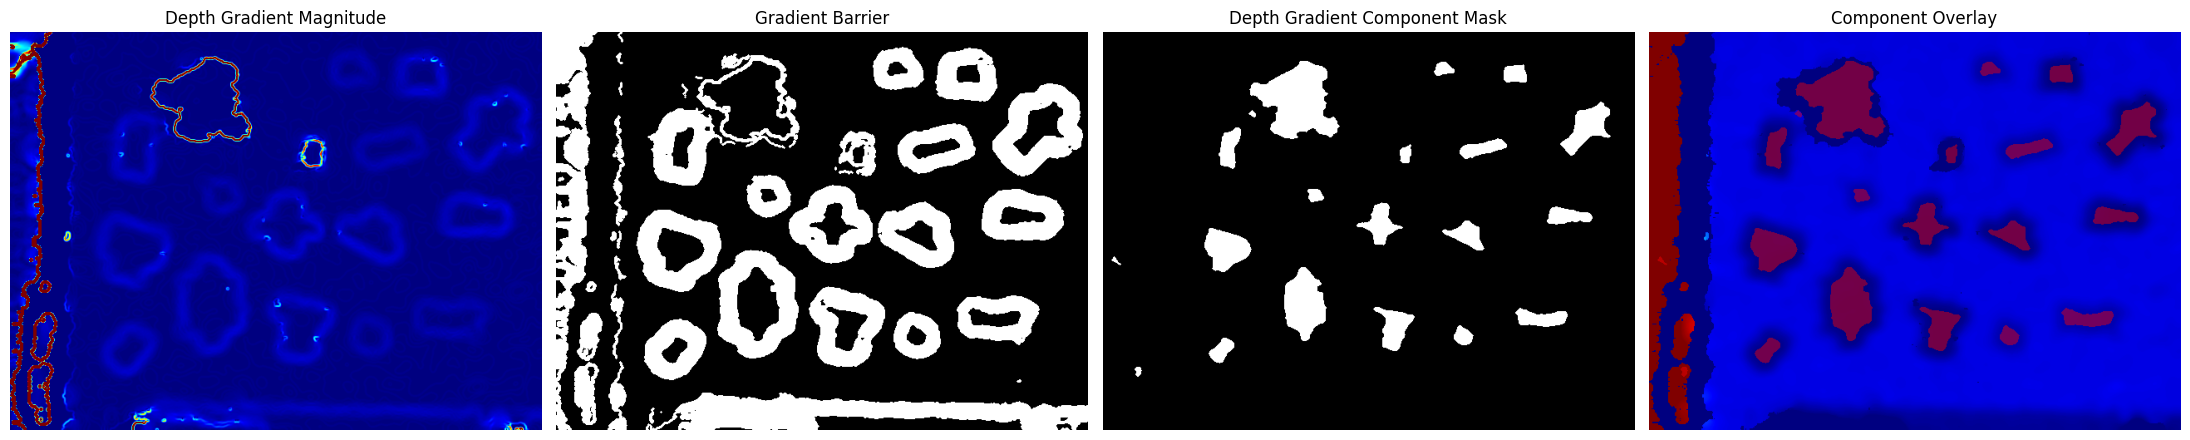

{'valid_count': 283348, 'grad_threshold_mode': 'percentile', 'grad_threshold_used': 4.396374607086182, 'grad_percentile': 70.0, 'grad_threshold_mm': 35.0, 'grad_p50': 2.490607261657715, 'grad_p90': 11.932427406311035, 'grad_p92': 12.848273277282715, 'grad_p95': 14.946257591247559, 'grad_p99': 212.2227317810041, 'component_count': 20, 'components': [{'label_id': 2, 'area': 5871, 'area_ratio': 0.019111328125, 'bbox': [176, 36, 109, 94], 'centroid': [233.8036109691705, 84.0364503491739], 'depth_median_mm': 478.0, 'depth_mean_mm': 478.40264892578125, 'depth_std_mm': 0.9445710778236389, 'depth_min_mm': 477.0000305175781, 'depth_max_mm': 483.0, 'grad_mean': 0.918580949306488, 'grad_median': 0.0}, {'label_id': 3, 'area': 287, 'area_ratio': 0.0009342447916666667, 'bbox': [398, 37, 25, 17], 'centroid': [409.13240418118465, 45.33101045296167], 'depth_median_mm': 553.0000610351562, 'depth_mean_mm': 553.4598999023438, 'depth_std_mm': 0.5821974873542786, 'depth_min_mm': 553.0000610351562, 'depth_ma

In [359]:
depth_gradient_component_mask, depth_gradient_component_info = create_depth_gradient_component_mask(
    depth_img=depth_filtered,
    valid_mask=valid_mask,
    depth_scale=intrinsics["depth"]["depth_scale"],

    grad_threshold_mode="percentile",
    grad_percentile=70.0,

    blur_ksize=3,
    barrier_dilate_kernel=3,

    min_area=40,
    max_area_ratio=0.35,
    max_component_depth_std_mm=100.0,

    ignore_border_touching=True,
    border_margin=3,

    close_kernel=5,
    open_kernel=3,

    show=True
)

print(depth_gradient_component_info)

# **flood fill**


[최종 검출 완료] 총 14개의 진짜 듀플로 브릭을 찾았습니다!


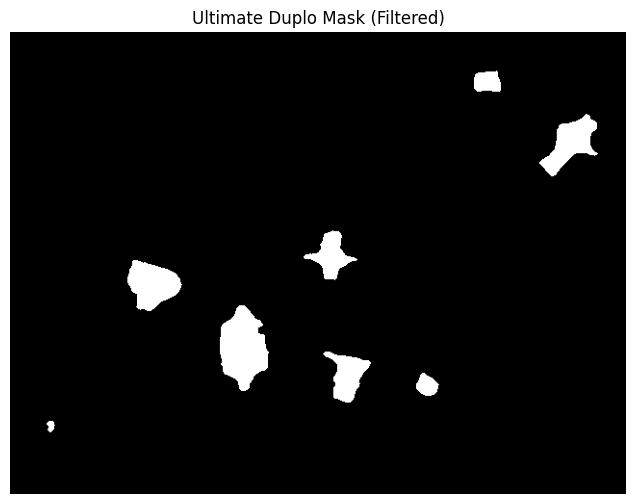

In [355]:
# ---------------------------------------------------------
# [Final Stage] 완벽한 마스크에서 '가짜(트리, 노이즈)'만 솎아내기
# ---------------------------------------------------------
final_duplo_mask = np.zeros_like(depth_gradient_component_mask)
valid_duplo_count = 0

# Stage 1에서 얻은 정보(depth_gradient_component_info)를 재활용합니다.
# 원본 마스크에서 덩어리들을 다시 분리해냅니다.
num_labels, labels = cv2.connectedComponents(depth_gradient_component_mask, connectivity=8)

for comp in depth_gradient_component_info['components']:
    label_id = comp['label_id']
    area = comp['area']
    depth = comp['depth_median_mm']

    # 🛑 1. 바닥 노이즈 제거 (카메라에서 800mm 이상 멀리 있으면 무조건 바닥)
    if depth > 800.0:
        continue

    # 🛑 2. 세워둔 거대 트리 제거 (면적이 2000 픽셀 이상으로 비정상적으로 크면 무시)
    # (실제 출력된 로그를 보고 일반 브릭보다 큰 면적 값을 커트라인으로 잡으세요)
    if area > 1800:
        continue
        
    # 위 두 조건을 모두 무사히 통과한 진짜 브릭만 최종 마스크에 색칠!
    final_duplo_mask[labels == label_id] = 255
    valid_duplo_count += 1

print(f"\n[최종 검출 완료] 총 {valid_duplo_count}개의 진짜 듀플로 브릭을 찾았습니다!")

# 결과 시각화
plt.figure(figsize=(8, 6))
plt.imshow(final_duplo_mask, cmap="gray")
plt.title("Ultimate Duplo Mask (Filtered)")
plt.axis("off")
plt.show()